# ThermoML → FAIRFluids Mapping

This notebook walks through the complete conversion of a ThermoML XML file into a `FAIRFluidsDocument` using `fairfluids.io.thermoml_to_fairfluids.convert`.

**Mapping specification:** `specifications/thermoml_to_fairfluids_mapping.md`

---
### Sections
1. [Setup & imports](#1-setup)
2. [Convert a single file](#2-single-file)
3. [Inspect the result](#3-inspect)
4. [Export to JSON](#4-export)
5. [Batch conversion of multiple files](#5-batch)


## 1 – Setup & imports <a id='1-setup'></a>

In [1]:
import sys
from pathlib import Path
import json
import pandas as pd

# Make the repo root importable when running from the Workflows/ folder
REPO_ROOT = Path(".").resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from fairfluids.core.lib import FAIRFluidsDocument, Properties, Parameters, Method, LitType
from fairfluids.io.thermoml_to_fairfluids import convert as thermoml_to_ff_convert
from fairfluids.operations import combine_compounds

DATA_DIR = REPO_ROOT / "transition_water" / "data"

print("Repo root :", REPO_ROOT)
print("Data dir  :", DATA_DIR)
print("XML files available:")
for f in sorted(DATA_DIR.rglob("*.xml")):
    print(" ", f.relative_to(REPO_ROOT))

Repo root : /home/sga/Code/FAIRFluids
Data dir  : /home/sga/Code/FAIRFluids/transition_water/data
XML files available:
  transition_water/data/chcl_glycerol/j.jct.2012.08.025.xml
  transition_water/data/glycerol_water/acs.jced.5b01015.xml
  transition_water/data/glycerol_water/j.jct.2014.06.031.xml
  transition_water/data/glycerol_water/j.tca.2013.07.012.xml
  transition_water/data/methanol_water/fluid.2014.07.013.xml
  transition_water/data/methanol_water/j.jct.2019.05.013.xml


## 2 – Convert a single file <a id='2-single-file'></a>

We use the glycerol / water dataset as the primary example.  
Die Funktion `convert` ist zustandslos; Sie können sie für jeden Aufruf wiederverwenden.

In [2]:
XML_FILE = Path("/home/sga/Code/FAIRFluids/fairfluids/data/thermoml_xml/spera_et_al_fpe_592_2025_114324.xml")

# Aktiviert PubChem-Enrichment (IUPAC, SMILES, CID, etc.) waehrend der Konvertierung.
doc = FAIRFluidsDocument.model_validate(
    thermoml_to_ff_convert(XML_FILE, fetch_from_pubchem=True)
)

print(f"✅ Conversion complete")
print(f"   Compounds  : {len(doc.compound)}")
print(f"   Fluids     : {len(doc.fluid)}")
total_meas = sum(len(f.sample.measurement) for f in doc.fluid)
print(f"   Measurements: {total_meas}")


✅ Conversion complete
   Compounds  : 6
   Fluids     : 92
   Measurements: 396


In [3]:
print(doc.model_dump_json(indent=2, include={"compound", "citation"}))

{
  "citation": {
    "litType": "journal",
    "author": [
      {
        "given_name": "Marcelle B. M.",
        "family_name": "Spera",
        "email": null,
        "orcid": null,
        "affiliation": null
      },
      {
        "given_name": "Samir",
        "family_name": "Darouich",
        "email": null,
        "orcid": null,
        "affiliation": null
      },
      {
        "given_name": "Jurgen",
        "family_name": "Pleiss",
        "email": null,
        "orcid": null,
        "affiliation": null
      },
      {
        "given_name": "Niels",
        "family_name": "Hansen",
        "email": null,
        "orcid": null,
        "affiliation": null
      }
    ],
    "doi": "10.1016/j.fluid.2024.114324",
    "page": "114324",
    "pub_name": "Fluid Phase Equilib.",
    "title": "Influence of water content on thermophysical properties of aqueous glyceline solutions predicted by molecular dynamics simulations",
    "lit_volume_num": "592",
    "url_citation": nul

In [4]:
choline_chloride = {
    "compoundID": "6209",
    "pubChemID": 6209,
    "commonName": "Choline Chloride",
    "name_IUPAC": "2-hydroxyethyl(trimethyl)azanium chloride",
    "standard_InChI": "InChI=1S/C5H14NO.ClH/c1-6(2,3)4-5-7;/h7H,4-5H2,1-3H3;1H/q+1;/p-1",
    "standard_InChI_key": "SGMZJAMFXRQCDB-UHFFFAOYSA-M",
}

old_cids = [305, 312]
new_cid = 6209
old_compound_ids = ["compound_choline", "compound_16887_00_6"]
old_compound_ids_set = set(old_compound_ids)

before_doc_compounds = [c.compoundID for c in doc.compound]
before_fluids_with_old = sum(
    1 for f in doc.fluid if any(cid in old_compound_ids_set for cid in (f.compounds or []))
)

print("Before combine:", [(c.compoundID, c.pubChemID, c.commonName) for c in doc.compound])
print(f"Fluids containing old IDs before combine: {before_fluids_with_old}")

doc = combine_compounds(
    doc,
    old_molecules=old_cids,
    new_molecule=new_cid,
    old_compound_ids=old_compound_ids,
)

after_doc_compounds = [c.compoundID for c in doc.compound]
after_fluids_with_old = sum(
    1 for f in doc.fluid if any(cid in old_compound_ids_set for cid in (f.compounds or []))
)

print("After combine :", [(c.compoundID, c.pubChemID, c.commonName) for c in doc.compound])
print(f"Fluids containing old IDs after combine : {after_fluids_with_old}")
print(
    "Top-level removal check:",
    all(cid not in after_doc_compounds for cid in old_compound_ids_set),
)

Before combine: [('compound_1', 305, 'Choline'), ('compound_2', 312, 'Chloride'), ('compound_3', 753, 'Glycerol'), ('compound_4', 962, 'Water'), ('compound_5', 280, 'Carbon Dioxide'), ('compound_6', 977, 'Oxygen')]
Fluids containing old IDs before combine: 0
=== Combining Compounds ===
Old molecules (pubChemIDs): [305, 312]
New molecule (pubChemID): 6209
Found old compound to remove: compound_1 (pubChemID: 305)
Found old compound to remove: compound_2 (pubChemID: 312)
Found old compound to remove via InChIKey fallback: compound_1 (InChIKey: OEYIOHPDSNJKLS-UHFFFAOYSA-N)
Found old compound to remove via InChIKey fallback: compound_2 (InChIKey: VEXZGXHMUGYJMC-UHFFFAOYSA-M)
Created new compound: compound_cholinechloride
Updated fluid compounds: ['compound_4', 'compound_3', 'compound_cholinechloride']
Added new parameter: parameter_mole_fraction_cholinechloride
Combined mole fractions: ['parameter_9', 'parameter_10'] -> 0.033
Combined mole fractions: ['parameter_9', 'parameter_10'] -> 0.033

In [5]:
print(doc.model_dump_json(indent=2, include={"compound"}))

{
  "compound": [
    {
      "compoundID": "compound_3",
      "pubChemID": 753,
      "commonName": "Glycerol",
      "SELFIE": null,
      "name_IUPAC": "propane-1,2,3-triol",
      "standard_InChI": "InChI=1S/C3H8O3/c4-1-3(6)2-5/h3-6H,1-2H2",
      "standard_InChI_key": "PEDCQBHIVMGVHV-UHFFFAOYSA-N",
      "molar_weigth": 92.09,
      "smiles_code": "C(C(CO)O)O",
      "sigma_profile": null
    },
    {
      "compoundID": "compound_4",
      "pubChemID": 962,
      "commonName": "Water",
      "SELFIE": null,
      "name_IUPAC": "oxidane",
      "standard_InChI": "InChI=1S/H2O/h1H2",
      "standard_InChI_key": "XLYOFNOQVPJJNP-UHFFFAOYSA-N",
      "molar_weigth": 18.015,
      "smiles_code": "O",
      "sigma_profile": null
    },
    {
      "compoundID": "compound_5",
      "pubChemID": 280,
      "commonName": "Carbon Dioxide",
      "SELFIE": null,
      "name_IUPAC": "carbon dioxide",
      "standard_InChI": "InChI=1S/CO2/c2-1-3",
      "standard_InChI_key": "CURLTUGMZLYLDI-U

In [6]:
from fairfluids.operations import calculate_ratio_of_solvent
doc = calculate_ratio_of_solvent(
    doc=doc,
    name="glyceline",
    compound_id_1="compound_3",
    compound_id_2="compound_cholinechloride",
    precision=0,
    print_reported_value=True,
)

=== Calculating Solvent Ratio: glyceline ===
Processing 92 fluids

--- Processing Fluid 1 ---
Skipping fluid 1: compound_3 not in fluid

--- Processing Fluid 2 ---
Skipping fluid 2: compound_3 not in fluid

--- Processing Fluid 3 ---
Added new parameter: parameter_solvent_ratio_glyceline
Measurement measurement_11: calculated ratio = 2.0
Measurement measurement_12: calculated ratio = 2.0
Measurement measurement_13: calculated ratio = 2.0
Measurement measurement_14: calculated ratio = 2.0
Measurement measurement_15: calculated ratio = 2.0

--- Processing Fluid 4 ---
Added new parameter: parameter_solvent_ratio_glyceline
Measurement measurement_16: calculated ratio = 2.0
Measurement measurement_17: calculated ratio = 2.0
Measurement measurement_18: calculated ratio = 2.0
Measurement measurement_19: calculated ratio = 2.0
Measurement measurement_20: calculated ratio = 2.0

--- Processing Fluid 5 ---
Added new parameter: parameter_solvent_ratio_glyceline
Measurement measurement_21: calcula

In [7]:
print(doc.model_dump_json(indent=2, include={"compound", "citation"}))

{
  "citation": {
    "litType": "journal",
    "author": [
      {
        "given_name": "Marcelle B. M.",
        "family_name": "Spera",
        "email": null,
        "orcid": null,
        "affiliation": null
      },
      {
        "given_name": "Samir",
        "family_name": "Darouich",
        "email": null,
        "orcid": null,
        "affiliation": null
      },
      {
        "given_name": "Jurgen",
        "family_name": "Pleiss",
        "email": null,
        "orcid": null,
        "affiliation": null
      },
      {
        "given_name": "Niels",
        "family_name": "Hansen",
        "email": null,
        "orcid": null,
        "affiliation": null
      }
    ],
    "doi": "10.1016/j.fluid.2024.114324",
    "page": "114324",
    "pub_name": "Fluid Phase Equilib.",
    "title": "Influence of water content on thermophysical properties of aqueous glyceline solutions predicted by molecular dynamics simulations",
    "lit_volume_num": "592",
    "url_citation": nul

## 3 – Inspect the result <a id='3-inspect'></a>

### 3.1 Citation

In [8]:
cit = doc.citation
print(f"Title       : {cit.title}")
print(f"DOI         : {cit.doi}")
print(f"Journal     : {cit.pub_name}")
print(f"Year        : {cit.publication_year}")
print(f"Lit. type   : {cit.litType}")
print(f"Volume      : {cit.lit_volume_num}")
print(f"Pages       : {cit.page}")
print()
print("Authors:")
for a in cit.author:
    print(f"  {a.family_name}, {a.given_name}")

Title       : Influence of water content on thermophysical properties of aqueous glyceline solutions predicted by molecular dynamics simulations
DOI         : 10.1016/j.fluid.2024.114324
Journal     : Fluid Phase Equilib.
Year        : 2025
Lit. type   : LitType.JOURNAL
Volume      : 592
Pages       : 114324

Authors:
  Spera, Marcelle B. M.
  Darouich, Samir
  Pleiss, Jurgen
  Hansen, Niels


### 3.2 Compounds

In [9]:
rows = [
    {
        "compoundID": c.compoundID,
        "commonName": c.commonName,
        "IUPAC": c.name_IUPAC,
        "InChIKey": c.standard_InChI_key,
        "PubChemID": c.pubChemID,
        "SMILES": c.smiles_code,
    }
    for c in doc.compound
]
pd.DataFrame(rows)

,compoundID,commonName,IUPAC,InChIKey,PubChemID,SMILES
0,compound_3,Glycerol,"propane-1,2,3-triol",PEDCQBHIVMGVHV-UHFFFAOYSA-N,753,C(C(CO)O)O
1,compound_4,Water,oxidane,XLYOFNOQVPJJNP-UHFFFAOYSA-N,962,O
2,compound_5,Carbon Dioxide,carbon dioxide,CURLTUGMZLYLDI-UHFFFAOYSA-N,280,C(=O)=O
3,compound_6,Oxygen,molecular oxygen,MYMOFIZGZYHOMD-UHFFFAOYSA-N,977,O=O
4,compound_cholinechloride,Choline Chloride,2-hydroxyethyl(trimethyl)azanium chloride,SGMZJAMFUVOLNK-UHFFFAOYSA-M,6209,C[N+](C)(C)CCO.[Cl-]


### 3.3 Fluids overview

In [10]:
for i, fluid in enumerate(doc.fluid):
    print(f"\n─── Fluid {i+1} ─────────────────────────────────────")
    print(f"  ID         : {fluid.fluidID}")
    print(f"  Compounds  : {fluid.compounds}")
    print(f"  Properties : {[p.propertyID for p in fluid.property]}")
    print(f"  Parameters : {[p.parameters for p in fluid.parameter]}")
    print(f"  Measurements: {len(fluid.sample.measurement)}")


─── Fluid 1 ─────────────────────────────────────
  ID         : ['fluid_1']
  Compounds  : ['compound_4']
  Properties : ['property_1']
  Parameters : [<Parameters.TEMPERATURE: 'Temperature'>, <Parameters.MOLE_FRACTION: 'Mole fraction'>, <Parameters.PRESSURE: 'Pressure'>]
  Measurements: 5

─── Fluid 2 ─────────────────────────────────────
  ID         : ['fluid_2']
  Compounds  : ['compound_4']
  Properties : ['property_2']
  Parameters : [<Parameters.TEMPERATURE: 'Temperature'>, <Parameters.MOLE_FRACTION: 'Mole fraction'>, <Parameters.PRESSURE: 'Pressure'>]
  Measurements: 5

─── Fluid 3 ─────────────────────────────────────
  ID         : ['fluid_3']
  Compounds  : ['compound_4', 'compound_3', 'compound_cholinechloride']
  Properties : ['property_3']
  Parameters : [<Parameters.TEMPERATURE: 'Temperature'>, <Parameters.MOLE_FRACTION: 'Mole fraction'>, <Parameters.MOLE_FRACTION: 'Mole fraction'>, <Parameters.PRESSURE: 'Pressure'>, <Parameters.MOLE_FRACTION: 'Mole fraction'>, <Parame

### 3.4 Properties – type and unit

In [11]:
rows = []
for fluid in doc.fluid:
    for prop in fluid.property:
        rows.append({
            "fluid_compounds": ", ".join(fluid.compounds),
            "propertyID": prop.propertyID,
            "enum_value": prop.properties.value if prop.properties else None,
            "unit_name": prop.unit.name if prop.unit else None,
            "unit_base_units": [
                f"{bu.kind}^{bu.exponent}"
                for bu in (prop.unit.base_units if prop.unit else [])
            ],
        })

df_props = pd.DataFrame(rows)
df_props

,fluid_compounds,propertyID,enum_value,unit_name,unit_base_units
0,compound_4,property_1,density,kilogram per cubic meter,"[mass^1, length^-3]"
1,compound_4,property_2,molarEnthalpy,kilojoule per mole,"[mass^1, length^2, time^-2, amount^-1]"
2,"compound_4, compound_3, compound_cholinechloride",property_3,density,kilogram per cubic meter,"[mass^1, length^-3]"
3,"compound_4, compound_3, compound_cholinechloride",property_4,molarEnthalpy,kilojoule per mole,"[mass^1, length^2, time^-2, amount^-1]"
4,"compound_4, compound_3, compound_cholinechloride",property_5,density,kilogram per cubic meter,"[mass^1, length^-3]"
...,...,...,...,...,...
87,"compound_4, compound_3, compound_6, compound_c...",property_88,henrysLawConstant,kilopascal cubic decimeter per mole,"[mass^1, length^2, time^-2, amount^-1]"
88,"compound_4, compound_3, compound_5, compound_c...",property_89,henrysLawConstant,kilopascal cubic decimeter per mole,"[mass^1, length^2, time^-2, amount^-1]"
89,"compound_4, compound_3, compound_6, compound_c...",property_90,henrysLawConstant,kilopascal cubic decimeter per mole,"[mass^1, length^2, time^-2, amount^-1]"
90,"compound_4, compound_5",property_91,henrysLawConstant,kilopascal cubic decimeter per mole,"[mass^1, length^2, time^-2, amount^-1]"


### 3.5 Parameters – type, unit, and associated compound

In [12]:
rows = []
for fluid in doc.fluid:
    for param in fluid.parameter:
        rows.append({
            "parameterID": param.parameterID,
            "enum_value": param.parameters.value if param.parameters else None,
            "unit_name": param.unit.name if param.unit else None,
            "associated_compounds": ", ".join(param.associated_compounds),
        })

pd.DataFrame(rows)

,parameterID,enum_value,unit_name,associated_compounds
0,parameter_1,Temperature,kelvin,
1,parameter_2,Mole fraction,dimensionless,compound_4
2,parameter_3,Pressure,kilopascal,
3,parameter_4,Temperature,kelvin,
4,parameter_5,Mole fraction,dimensionless,compound_4
...,...,...,...,...
541,parameter_542,Mole fraction,dimensionless,compound_4
542,parameter_543,Mole fraction,dimensionless,
543,parameter_544,Mole fraction,dimensionless,
544,parameter_545,Mole fraction,dimensionless,


### 3.6 Measurement data — first fluid as a DataFrame

In [13]:
def fluid_to_dataframe(fluid) -> pd.DataFrame:
    """Unpack a Fluid's measurements into a flat DataFrame."""
    from fairfluids.core.functionalities import _get_measurements
    
    rows = []
    for meas in _get_measurements(fluid):
        row = {
            "measurement_id": meas.measurement_id,
            "source_doi": meas.source_doi,
            "method": meas.method.value if meas.method else None,
        }
        for pv in meas.propertyValue:
            row[f"prop_{pv.properties}"] = pv.propValue
            if pv.uncertainty is not None:
                row[f"prop_{pv.properties}_unc"] = pv.uncertainty
        for pv in meas.parameterValue:
            row[f"param_{pv.parameters}"] = pv.paramValue
        rows.append(row)
    return pd.DataFrame(rows)


# Show the first fluid (pure glycerol or mixture depending on the file)
fluid0 = doc.fluid[0]
print(f"Fluid compounds: {fluid0.compounds}")
df0 = fluid_to_dataframe(fluid0)
df0.head(10)

Fluid compounds: ['compound_4']


,measurement_id,source_doi,method,prop_Properties.DENSITY,prop_Properties.DENSITY_unc,param_Parameters.TEMPERATURE,param_Parameters.MOLE_FRACTION,param_Parameters.PRESSURE
0,measurement_1,10.1016/j.fluid.2024.114324,literature,989.26692,0.132553,313.15,1.0,100.0
1,measurement_2,10.1016/j.fluid.2024.114324,literature,984.23857,0.029222,323.15,1.0,100.0
2,measurement_3,10.1016/j.fluid.2024.114324,literature,978.73098,0.470517,333.15,1.0,100.0
3,measurement_4,10.1016/j.fluid.2024.114324,literature,972.22267,0.368699,343.15,1.0,100.0
4,measurement_5,10.1016/j.fluid.2024.114324,literature,965.13213,0.251989,353.15,1.0,100.0


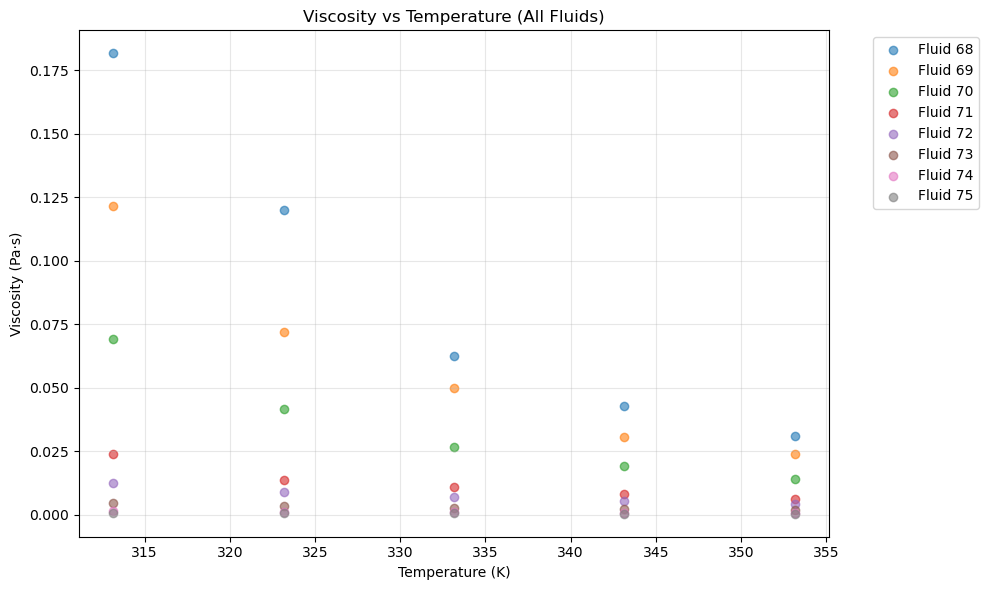

In [14]:
# Plot viscosity vs temperature for all fluids
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Use the enum values directly instead of IDs
viscosity_col = f"prop_{Properties.VISCOSITY}"
temp_col = f"param_{Parameters.TEMPERATURE}"

# Plot each fluid's viscosity data
plotted_any = False
for i, fluid in enumerate(doc.fluid):
    df = fluid_to_dataframe(fluid)
    if viscosity_col in df.columns and temp_col in df.columns:
        ax.scatter(df[temp_col], df[viscosity_col], alpha=0.6, label=f"Fluid {i}")
        plotted_any = True

if plotted_any:
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("Viscosity (Pa·s)")
    ax.set_title("Viscosity vs Temperature (All Fluids)")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    print("No matching viscosity/temperature columns found in any fluid.")

plt.tight_layout()
plt.show()

### 3.7 Quick overview of all measurement data

In [15]:
all_dfs = []
for i, fluid in enumerate(doc.fluid):
    df = fluid_to_dataframe(fluid)
    df.insert(0, "fluid_idx", i)
    df.insert(1, "fluid_compounds", ", ".join(fluid.compounds))
    all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)
print(f"Total rows: {len(df_all)}")
print(f"Columns   : {list(df_all.columns)}")
df_all.describe()

Total rows: 396
Columns   : ['fluid_idx', 'fluid_compounds', 'measurement_id', 'source_doi', 'method', 'prop_Properties.DENSITY', 'prop_Properties.DENSITY_unc', 'param_Parameters.TEMPERATURE', 'param_Parameters.MOLE_FRACTION', 'param_Parameters.PRESSURE', 'prop_Properties.MOLAR_ENTHALPY', 'prop_Properties.MOLAR_ENTHALPY_unc', 'param_Parameters.SOLVENT_AMOUNT_RATIO_OF_COMPONENT_TO_OTHER_COMPONENT_OF_BINARY_SOLVENT', 'prop_Properties.ISOBARIC_EXPANSION_COEFFICIENT', 'prop_Properties.ISOBARIC_EXPANSION_COEFFICIENT_unc', 'prop_Properties.EXCESS_MOLAR_VOLUME', 'prop_Properties.EXCESS_MOLAR_VOLUME_unc', 'prop_Properties.EXCESS_MOLAR_ENTHALPY', 'prop_Properties.EXCESS_MOLAR_ENTHALPY_unc', 'prop_Properties.DIFFUSION_COEFFICIENT', 'prop_Properties.DIFFUSION_COEFFICIENT_unc', 'prop_Properties.VISCOSITY', 'prop_Properties.VISCOSITY_unc', 'prop_Properties.HENRYS_LAW_CONSTANT', 'prop_Properties.HENRYS_LAW_CONSTANT_unc']


,fluid_idx,prop_Properties.DENSITY,prop_Properties.DENSITY_unc,param_Parameters.TEMPERATURE,param_Parameters.MOLE_FRACTION,param_Parameters.PRESSURE,prop_Properties.MOLAR_ENTHALPY,prop_Properties.MOLAR_ENTHALPY_unc,param_Parameters.SOLVENT_AMOUNT_RATIO_OF_COMPONENT_TO_OTHER_COMPONENT_OF_BINARY_SOLVENT,prop_Properties.ISOBARIC_EXPANSION_COEFFICIENT,...,prop_Properties.EXCESS_MOLAR_VOLUME,prop_Properties.EXCESS_MOLAR_VOLUME_unc,prop_Properties.EXCESS_MOLAR_ENTHALPY,prop_Properties.EXCESS_MOLAR_ENTHALPY_unc,prop_Properties.DIFFUSION_COEFFICIENT,prop_Properties.DIFFUSION_COEFFICIENT_unc,prop_Properties.VISCOSITY,prop_Properties.VISCOSITY_unc,prop_Properties.HENRYS_LAW_CONSTANT,prop_Properties.HENRYS_LAW_CONSTANT_unc
count,396.000000,40.000000,40.000000,396.000000,396.000000,396.0,40.000000,40.000000,379.000000,40.000000,...,40.000000,40.000000,40.000000,40.000000,1.400000e+02,1.400000e+02,40.000000,40.000000,16.000000,16.000000
mean,39.358586,1119.188298,0.182956,332.341919,0.191624,100.0,-73349.180235,34.238920,1.894459,0.000621,...,-0.290690,0.011539,-563.356182,24.392625,6.061929e-06,3.785714e-07,0.025654,0.002881,106505.345940,607.931555
std,23.368435,66.111531,0.124089,14.420574,0.169778,0.0,91882.264662,19.060019,0.447741,0.000049,...,0.211311,0.010574,440.182174,23.492094,1.113752e-05,8.088348e-07,0.039474,0.010190,109281.000401,508.675465
min,0.000000,965.132130,0.028812,313.150000,0.000000,100.0,-310272.162230,7.783080,0.000000,0.000459,...,-0.577090,0.000000,-1173.026800,0.000000,5.000000e-08,0.000000e+00,0.000318,0.000001,5019.531591,57.920518
25%,19.000000,1091.807407,0.086324,323.150000,0.083000,100.0,-104667.779288,22.096036,2.000000,0.000596,...,-0.483337,0.001881,-908.081630,4.588382,4.600000e-07,0.000000e+00,0.001709,0.000021,6768.292981,344.598898
50%,39.000000,1146.660040,0.168423,333.150000,0.167000,100.0,-40472.874330,30.138173,2.000000,0.000619,...,-0.317140,0.009638,-565.611920,18.049968,1.805000e-06,0.000000e+00,0.008370,0.000154,58867.706032,469.807514
75%,59.000000,1166.327975,0.230431,343.150000,0.300000,100.0,-5898.821788,42.822521,2.000000,0.000636,...,-0.125085,0.018300,-202.212000,34.915184,6.155000e-06,1.000000e-06,0.030531,0.001419,228755.908522,700.585954
max,91.000000,1187.320010,0.527433,353.150000,1.000000,100.0,9602.262230,98.320649,2.000000,0.000774,...,0.000000,0.038786,0.000000,77.010413,6.872000e-05,6.000000e-06,0.181663,0.063329,250905.087694,2250.965176


### 3.8 Validate: mole fractions sum to 1 in mixture fluids

In [16]:
# Validate that combine_compounds propagated through the whole document
old_cids = {305, 312}
new_cid = 6209
old_compound_ids = {"compound_choline", "compound_16887_00_6"}

present_cids = {c.pubChemID for c in doc.compound if c.pubChemID is not None}
print("Combine check:")
print("  old CIDs still present:", sorted(old_cids & present_cids))
print("  new CID present       :", new_cid in present_cids)

leftover_in_fluids = []
leftover_in_samples = []
leftover_in_parameters = []

for i, fluid in enumerate(doc.fluid):
    if any(cid in old_compound_ids for cid in (fluid.compounds or [])):
        leftover_in_fluids.append(i)

    if fluid.sample and any(cid in old_compound_ids for cid in (fluid.sample.associated_compounds or [])):
        leftover_in_samples.append(i)

    for param in (fluid.parameter or []):
        if any(cid in old_compound_ids for cid in (param.associated_compounds or [])):
            leftover_in_parameters.append(i)
            break

print("  leftover old IDs in fluid.compounds         :", len(leftover_in_fluids))
print("  leftover old IDs in sample.associated_compounds:", len(leftover_in_samples))
print("  leftover old IDs in parameter.associated_compounds:", len(leftover_in_parameters))

if leftover_in_fluids or leftover_in_samples or leftover_in_parameters:
    print("\nFirst affected fluid indices:")
    print("  compounds:", leftover_in_fluids[:10])
    print("  sample   :", leftover_in_samples[:10])
    print("  parameter:", leftover_in_parameters[:10])

print("\nMole-fraction sum checks:")
for i, fluid in enumerate(doc.fluid):
    if len(fluid.compounds) < 2:
        continue

    mf_pids = [
        p.parameterID
        for p in fluid.parameter
        if p.parameters == Parameters.MOLE_FRACTION
    ]
    if not mf_pids:
        continue

    measurements = fluid.sample.measurement if fluid.sample else []

    errors = []
    for meas in measurements:
        total = sum(
            pv.paramValue
            for pv in meas.parameterValue
            if pv.parameterID in mf_pids and pv.paramValue is not None
        )
        if abs(total - 1.0) > 1e-6:
            errors.append(total)

    status = "✅" if not errors else f"❌  {len(errors)} bad rows"
    print(f"Fluid {i} ({', '.join(fluid.compounds)}): mole-fraction sum check {status}")

Combine check:
  old CIDs still present: []
  new CID present       : True
  leftover old IDs in fluid.compounds         : 0
  leftover old IDs in sample.associated_compounds: 0
  leftover old IDs in parameter.associated_compounds: 0

Mole-fraction sum checks:
Fluid 2 (compound_4, compound_3, compound_cholinechloride): mole-fraction sum check ✅
Fluid 3 (compound_4, compound_3, compound_cholinechloride): mole-fraction sum check ✅
Fluid 4 (compound_4, compound_3, compound_cholinechloride): mole-fraction sum check ✅
Fluid 5 (compound_4, compound_3, compound_cholinechloride): mole-fraction sum check ✅
Fluid 6 (compound_4, compound_3, compound_cholinechloride): mole-fraction sum check ✅
Fluid 7 (compound_4, compound_3, compound_cholinechloride): mole-fraction sum check ✅
Fluid 8 (compound_4, compound_3, compound_cholinechloride): mole-fraction sum check ✅
Fluid 9 (compound_4, compound_3, compound_cholinechloride): mole-fraction sum check ✅
Fluid 10 (compound_4, compound_3, compound_cholinec

## 4 – Export to JSON <a id='4-export'></a>

In [17]:
OUTPUT_DIR = REPO_ROOT / "Workflows" / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

out_path = OUTPUT_DIR / "glycerol_water_j.jct.2014.06.031.json"
doc.save_to_json(str(out_path))
print(f"Saved → {out_path}")

# Verify round-trip: file size and basic key presence
with open(out_path) as f:
    raw = json.load(f)
print(f"Top-level keys : {list(raw.keys())}")
print(f"File size      : {out_path.stat().st_size / 1024:.1f} kB")

Saved → /home/sga/Code/FAIRFluids/Workflows/outputs/glycerol_water_j.jct.2014.06.031.json
Top-level keys : ['version', 'citation', 'compound', 'fluid']
File size      : 1492.7 kB


### 4.1 Preview the JSON structure

In [18]:
# Show the first fluid with its first 2 measurements
preview = dict(raw)
if preview.get("fluid"):
    preview["fluid"] = [dict(preview["fluid"][0])]
    preview["fluid"][0]["measurement"] = preview["fluid"][0].get("measurement", [])[:2]

print(json.dumps(preview, indent=2)[:8000], "\n...")

{
  "version": null,
  "citation": {
    "litType": "journal",
    "author": [
      {
        "given_name": "Marcelle B. M.",
        "family_name": "Spera",
        "email": null,
        "orcid": null,
        "affiliation": null
      },
      {
        "given_name": "Samir",
        "family_name": "Darouich",
        "email": null,
        "orcid": null,
        "affiliation": null
      },
      {
        "given_name": "Jurgen",
        "family_name": "Pleiss",
        "email": null,
        "orcid": null,
        "affiliation": null
      },
      {
        "given_name": "Niels",
        "family_name": "Hansen",
        "email": null,
        "orcid": null,
        "affiliation": null
      }
    ],
    "doi": "10.1016/j.fluid.2024.114324",
    "page": "114324",
    "pub_name": "Fluid Phase Equilib.",
    "title": "Influence of water content on thermophysical properties of aqueous glyceline solutions predicted by molecular dynamics simulations",
    "lit_volume_num": "592",
    

## 5 – Batch conversion of multiple files <a id='5-batch'></a>

All ThermoML files in `transition_water/data/` are converted in one loop.  
Jeder Durchlauf ruft `convert` auf; die Pipeline erzeugt jeweils ein neues Dokument.

In [19]:
xml_files = sorted(DATA_DIR.rglob("*.xml"))
print(f"Found {len(xml_files)} XML file(s)\n")

results = {}  # filename → FAIRFluidsDocument
errors  = {}

for xml_path in xml_files:
    label = xml_path.name
    print(f"{'='*60}")
    print(f"Processing: {label}")
    print(f"{'='*60}")
    try:
        converted = FAIRFluidsDocument.model_validate(thermoml_to_ff_convert(xml_path))
        results[label] = converted

        n_compounds   = len(converted.compound)
        n_fluids      = len(converted.fluid)
        # Use _get_measurements helper to safely access measurements
        from fairfluids.core.functionalities import _get_measurements
        n_measurements = sum(len(list(_get_measurements(f))) for f in converted.fluid)
        print(f"✅ Compounds: {n_compounds}  |  Fluids: {n_fluids}  |  Measurements: {n_measurements}")
        print(f"   DOI: {converted.citation.doi if converted.citation else 'n/a'}")
        cnames = [c.commonName for c in converted.compound if c.commonName]
        print(f"   Compounds: {cnames}")
    except Exception as exc:
        errors[label] = str(exc)
        print(f"❌ ERROR: {exc}")
    print()

print(f"\nDone. {len(results)} succeeded, {len(errors)} failed.")

No FAIRFluids property mapping for ThermoML name: 'Molality, mol/kg'
/home/sga/Code/FAIRFluids/fairfluids/thermoml_to_fairfluids/fairfluids_builder.py:331: UserWarning: Unknown ThermoML property encountered: 'Molality, mol/kg'
  mapped_prop = PropertyMapper.map(cp.thermoml_name)
No FAIRFluids property mapping for ThermoML name: 'Mole fraction'
/home/sga/Code/FAIRFluids/fairfluids/thermoml_to_fairfluids/fairfluids_builder.py:331: UserWarning: Unknown ThermoML property encountered: 'Mole fraction'
  mapped_prop = PropertyMapper.map(cp.thermoml_name)
No FAIRFluids property mapping for ThermoML name: 'Mole fraction'
No FAIRFluids property mapping for ThermoML name: 'Mole fraction'


Found 6 XML file(s)

Processing: j.jct.2012.08.025.xml
✅ Compounds: 3  |  Fluids: 1  |  Measurements: 40
   DOI: 10.1016/j.jct.2012.08.025
   Compounds: ['carbon dioxide', 'choline chloride', 'glycerol']

Processing: acs.jced.5b01015.xml
✅ Compounds: 3  |  Fluids: 3  |  Measurements: 144
   DOI: 10.1021/acs.jced.5b01015
   Compounds: ['propan-1-ol', 'glycerol', 'water']

Processing: j.jct.2014.06.031.xml
✅ Compounds: 2  |  Fluids: 6  |  Measurements: 570
   DOI: 10.1016/j.jct.2014.06.031
   Compounds: ['glycerol', 'water']

Processing: j.tca.2013.07.012.xml
✅ Compounds: 2  |  Fluids: 3  |  Measurements: 321
   DOI: 10.1016/j.tca.2013.07.012
   Compounds: ['glycerol', 'water']

Processing: fluid.2014.07.013.xml
✅ Compounds: 3  |  Fluids: 1  |  Measurements: 55
   DOI: 10.1016/j.fluid.2014.07.013
   Compounds: ['4-amino-N-2-pyrimidinylbenzenesulfonamide', 'methanol', 'water']

Processing: j.jct.2019.05.013.xml
✅ Compounds: 2  |  Fluids: 3  |  Measurements: 25
   DOI: 10.1016/j.jct.2019.0

### 5.1 Batch summary table

In [20]:
from fairfluids.core.functionalities import _get_measurements

summary_rows = []
for fname, d in results.items():
    summary_rows.append({
        "file": fname,
        "doi": d.citation.doi if d.citation else None,
        "year": d.citation.publication_year if d.citation else None,
        "n_compounds": len(d.compound),
        "compound_names": ", ".join(
            c.commonName for c in d.compound if c.commonName
        ),
        "n_fluids": len(d.fluid),
        "n_measurements": sum(len(list(_get_measurements(f))) for f in d.fluid),
        "properties": ", ".join(
            sorted({
                p.properties.value
                for f in d.fluid
                for p in f.property
                if p.properties
            })
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,file,doi,year,n_compounds,compound_names,n_fluids,n_measurements,properties
0,j.jct.2012.08.025.xml,10.1016/j.jct.2012.08.025,2013,3,"carbon dioxide, choline chloride, glycerol",1,40,
1,acs.jced.5b01015.xml,10.1021/acs.jced.5b01015,2016,3,"propan-1-ol, glycerol, water",3,144,vaporPressure
2,j.jct.2014.06.031.xml,10.1016/j.jct.2014.06.031,2014,2,"glycerol, water",6,570,"density, specificVolume"
3,j.tca.2013.07.012.xml,10.1016/j.tca.2013.07.012,2013,2,"glycerol, water",3,321,density
4,fluid.2014.07.013.xml,10.1016/j.fluid.2014.07.013,2014,3,"4-amino-N-2-pyrimidinylbenzenesulfonamide, met...",1,55,
5,j.jct.2019.05.013.xml,10.1016/j.jct.2019.05.013,2019,2,"water, methanol",3,25,"density, refractiveIndex, viscosity"


### 5.2 Batch export – one JSON file per source XML

In [21]:
BATCH_OUTPUT_DIR = REPO_ROOT / "Workflows" / "outputs"
BATCH_OUTPUT_DIR.mkdir(exist_ok=True)

for fname, d in results.items():
    out = BATCH_OUTPUT_DIR / fname.replace(".xml", ".json")
    d.save_to_json(str(out))
    size_kb = out.stat().st_size / 1024
    print(f"  Saved {fname:40s} → {out.name}  ({size_kb:.1f} kB)")

  Saved j.jct.2012.08.025.xml                    → j.jct.2012.08.025.json  (67.1 kB)
  Saved acs.jced.5b01015.xml                     → acs.jced.5b01015.json  (232.1 kB)
  Saved j.jct.2014.06.031.xml                    → j.jct.2014.06.031.json  (881.8 kB)
  Saved j.tca.2013.07.012.xml                    → j.tca.2013.07.012.json  (494.6 kB)
  Saved fluid.2014.07.013.xml                    → fluid.2014.07.013.json  (89.6 kB)
  Saved j.jct.2019.05.013.xml                    → j.jct.2019.05.013.json  (51.2 kB)


---
## Appendix – mapping decisions summary

| # | Issue | Decision |
|---|-------|----------|
| P1 | Unit strings in ThermoML enums | Parsed from `ePropName` / `eTemperature` etc.; looked up in `UNIT_DEFINITIONS`; unknown units stored as name-only |
| P2 | Variable vs. Constraint | Both → `Parameter[]`; distinction preserved only in `parameterID` prefix |
| P3 | pH as parameter | Mapped to `Parameter` when in variable/constraint; `Properties.PH` when in property group |
| P4 | Compound index linking | `nOrgNum` integer → `compound_<name>` string ID |
| P5 | Uncertainty | Option B: `nCombExpandUncertValue` preferred; fallback to `nCombStdUncertValue` then `PropUncertainty.nStdUncertValue` |
| P6 | Author names | Split on `,` / `;`; `[bracketed content]` stripped |
| P7 | Sample placement | Not mapped (FAIRFluids lib places `Measurement` directly on `Fluid`) |
| P8 | Unmapped property groups | Skipped with `propertyID = "property_<num>"` and no `Properties` enum value |
| P9 | Reaction data | Silently ignored |
| P10 | `ePresentation` | Stored as JSON snippet in `Measurement.method_description` |